# 🌳 Decision Tree Classifier

A fundamentally different approach from every algorithm so far: no probability model (Naive Bayes), no distance metric (KNN), no linear score (Logistic Regression) — just a sequence of "if feature $X$ is above/below threshold $t$, go left/right" rules, learned directly from data.

📖 Full mathematical explanation (Gini impurity, entropy, information gain derivation): [README.md](README.md)


## 1. Setup & Dataset


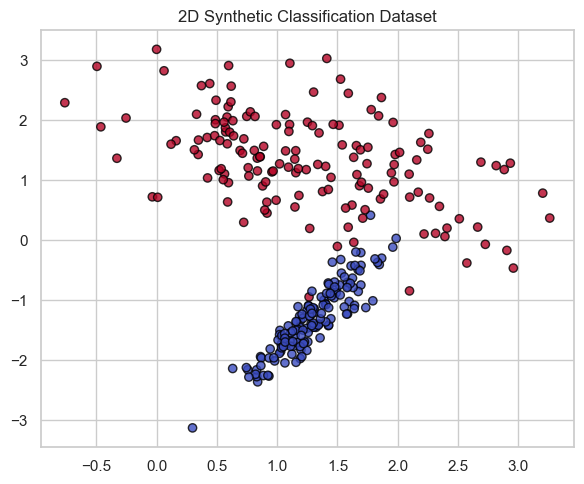

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
np.random.seed(42)

X_2d, y_2d = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.3, random_state=42
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.8)
ax.set_title("2D Synthetic Classification Dataset")
plt.tight_layout()
plt.show()


## 2. Gini Impurity — Measuring How "Mixed" a Node Is

A pure node (all one class) has Gini impurity 0; a perfectly mixed 50/50 binary node has Gini impurity 0.5. Formula and derivation in the README — here we compute it directly on a few example splits.


In [2]:
def gini_impurity(y):
    if len(y) == 0:
        return 0
    proportions = np.array([np.mean(y == c) for c in np.unique(y)])
    return 1 - np.sum(proportions ** 2)

pure_node = np.array([0, 0, 0, 0, 0])
mixed_node = np.array([0, 0, 0, 1, 1])
perfectly_mixed_node = np.array([0, 0, 1, 1])

print(f"Pure node {pure_node}:              Gini = {gini_impurity(pure_node):.3f}")
print(f"Mixed node {mixed_node}:             Gini = {gini_impurity(mixed_node):.3f}")
print(f"Perfectly mixed node {perfectly_mixed_node}: Gini = {gini_impurity(perfectly_mixed_node):.3f}")


Pure node [0 0 0 0 0]:              Gini = 0.000
Mixed node [0 0 0 1 1]:             Gini = 0.480
Perfectly mixed node [0 0 1 1]: Gini = 0.500


## 3. Entropy & Information Gain

Entropy is an alternative impurity measure from information theory; **information gain** is the reduction in impurity a split achieves — the actual quantity a tree greedily maximizes at every node.


In [3]:
def entropy(y):
    if len(y) == 0:
        return 0
    proportions = np.array([np.mean(y == c) for c in np.unique(y)])
    proportions = proportions[proportions > 0]   # avoid log(0)
    return -np.sum(proportions * np.log2(proportions))

def information_gain(parent, left, right):
    n = len(parent)
    weighted_child_entropy = (len(left) / n) * entropy(left) + (len(right) / n) * entropy(right)
    return entropy(parent) - weighted_child_entropy

parent_node = np.array([0, 0, 0, 1, 1, 1])
left_split = np.array([0, 0, 0])
right_split = np.array([1, 1, 1])

print(f"Parent entropy: {entropy(parent_node):.3f}")
print(f"Information gain from a PERFECT split: {information_gain(parent_node, left_split, right_split):.3f}")

bad_left, bad_right = np.array([0, 0, 1]), np.array([0, 1, 1])
print(f"Information gain from a BAD (uninformative) split: {information_gain(parent_node, bad_left, bad_right):.3f}")


Parent entropy: 1.000
Information gain from a PERFECT split: 1.000
Information gain from a BAD (uninformative) split: 0.082


## 4. Finding the Best Split — Brute Force Search

At every node, a decision tree tries every feature and every possible threshold, and picks whichever split maximizes information gain (or minimizes weighted Gini). We implement this search directly on the 2D dataset's first split.


In [4]:
def find_best_split(X, y):
    best_gain = -1
    best_feature, best_threshold = None, None

    for feature_idx in range(X.shape[1]):
        thresholds = np.unique(X[:, feature_idx])
        for threshold in thresholds:
            left_mask = X[:, feature_idx] <= threshold
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            gain = information_gain(y, y[left_mask], y[right_mask])
            if gain > best_gain:
                best_gain = gain
                best_feature, best_threshold = feature_idx, threshold

    return best_feature, best_threshold, best_gain

best_feature, best_threshold, best_gain = find_best_split(X_2d, y_2d)
print(f"Best split: feature {best_feature}, threshold {best_threshold:.3f}, information gain {best_gain:.3f}")


Best split: feature 1, threshold -0.111, information gain 0.843


## 5. Visualizing the First Split

The single best split found above, drawn directly on the data — this is exactly the rule the root node of a decision tree would learn first.


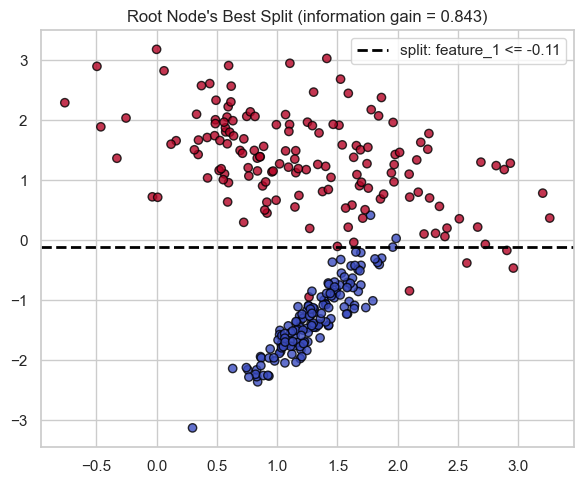

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.8)
if best_feature == 0:
    ax.axvline(best_threshold, color="black", linewidth=2, linestyle="--", label=f"split: feature_0 <= {best_threshold:.2f}")
else:
    ax.axhline(best_threshold, color="black", linewidth=2, linestyle="--", label=f"split: feature_1 <= {best_threshold:.2f}")
ax.set_title(f"Root Node's Best Split (information gain = {best_gain:.3f})")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Building a Full Tree Recursively

A full decision tree just repeats section 4's best-split search on each resulting child node, recursively, until a stopping condition (max depth, pure node, or too few samples) is reached. A small from-scratch recursive tree, capped at depth 3.


In [6]:
class SimpleTreeNode:
    def __init__(self, depth=0, max_depth=3):
        self.max_depth = max_depth
        self.depth = depth
        self.is_leaf = False
        self.prediction = None
        self.feature, self.threshold = None, None
        self.left, self.right = None, None

    def fit(self, X, y):
        if self.depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < 4:
            self.is_leaf = True
            self.prediction = np.bincount(y).argmax()
            return

        feature, threshold, gain = find_best_split(X, y)
        if feature is None or gain <= 0:
            self.is_leaf = True
            self.prediction = np.bincount(y).argmax()
            return

        self.feature, self.threshold = feature, threshold
        left_mask = X[:, feature] <= threshold
        self.left = SimpleTreeNode(self.depth + 1, self.max_depth)
        self.right = SimpleTreeNode(self.depth + 1, self.max_depth)
        self.left.fit(X[left_mask], y[left_mask])
        self.right.fit(X[~left_mask], y[~left_mask])

    def predict_one(self, x):
        if self.is_leaf:
            return self.prediction
        branch = self.left if x[self.feature] <= self.threshold else self.right
        return branch.predict_one(x)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

scratch_tree = SimpleTreeNode(max_depth=3)
scratch_tree.fit(X_2d, y_2d)
scratch_preds = scratch_tree.predict(X_2d)
print("From-scratch tree (max_depth=3) training accuracy:", round(accuracy_score(y_2d, scratch_preds), 4))


From-scratch tree (max_depth=3) training accuracy: 0.9933


## 7. Comparing Against scikit-learn

Verifying the from-scratch recursive tree against `DecisionTreeClassifier` at the same `max_depth` — should match closely, since both greedily optimize the same criterion.


In [7]:
sklearn_tree = DecisionTreeClassifier(max_depth=3, criterion="entropy", random_state=42)
sklearn_tree.fit(X_2d, y_2d)
sklearn_preds = sklearn_tree.predict(X_2d)

print(f"From-scratch accuracy: {accuracy_score(y_2d, scratch_preds):.4f}")
print(f"sklearn accuracy:      {accuracy_score(y_2d, sklearn_preds):.4f}")
print(f"Prediction agreement:  {(scratch_preds == sklearn_preds).mean():.4f}")


From-scratch accuracy: 0.9933
sklearn accuracy:      0.9933
Prediction agreement:  1.0000


## 8. Visualizing the Tree Structure

`plot_tree` renders the actual learned rules — every internal node's split condition, every leaf's predicted class, and the Gini/entropy value at each node, directly readable without any black-box interpretation needed.


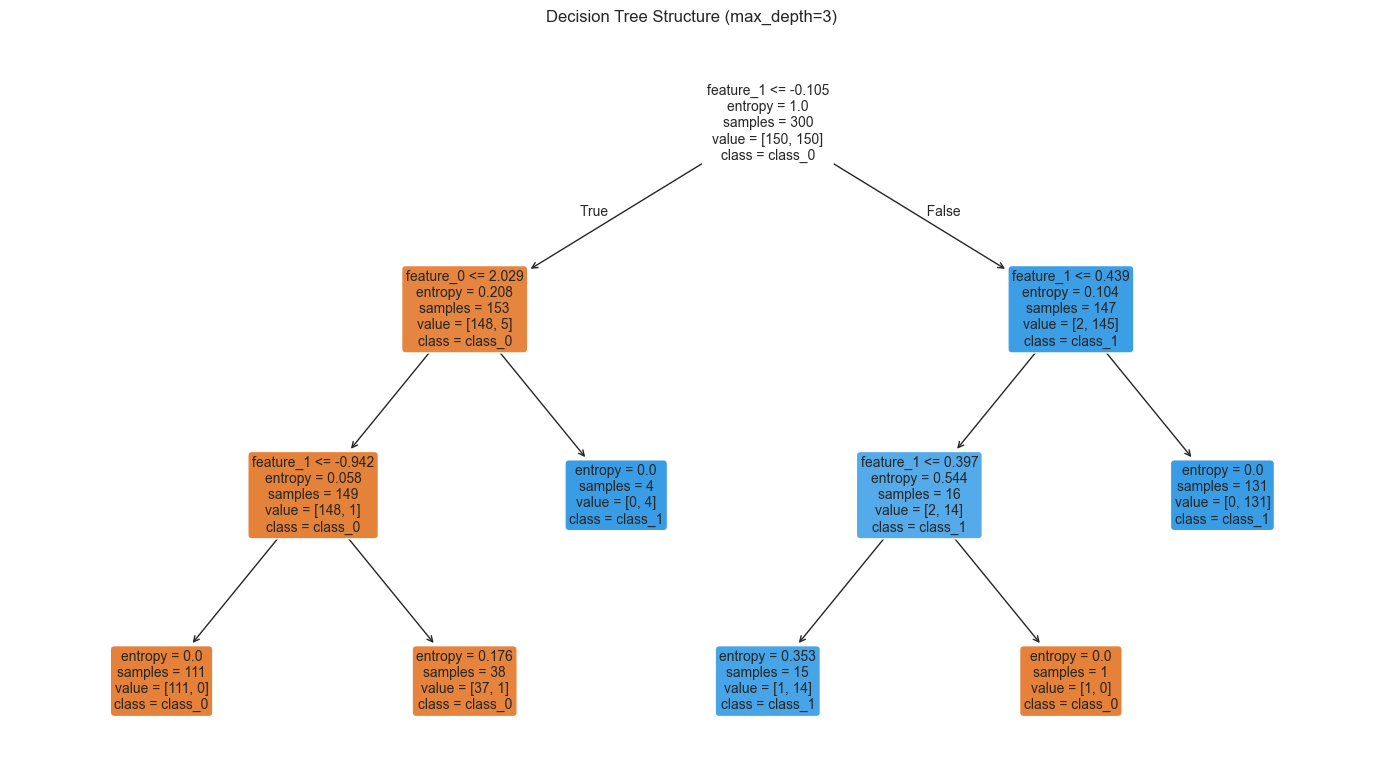

In [8]:
fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(sklearn_tree, feature_names=["feature_0", "feature_1"], class_names=["class_0", "class_1"],
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title("Decision Tree Structure (max_depth=3)")
plt.tight_layout()
plt.show()


## 9. Decision Boundary — the Axis-Aligned "Staircase"

Because every split is a threshold on a single feature, a decision tree's decision boundary is always made of axis-aligned rectangular regions — a distinctive "staircase" shape, geometrically unlike Logistic Regression's straight line or GaussianNB's curved boundary.


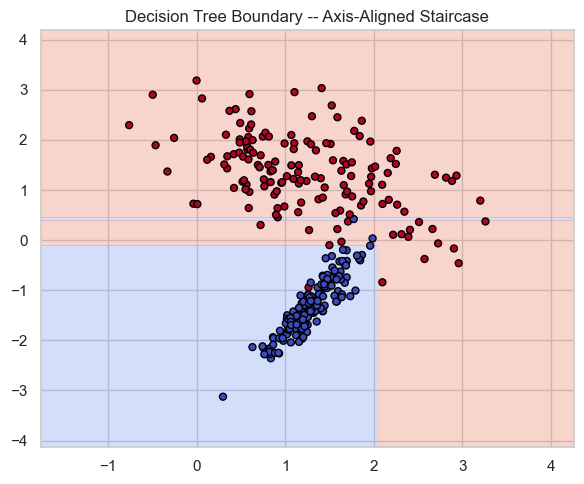

In [9]:
def plot_tree_boundary(ax, model, X, y, title):
    x1_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)
    x2_range = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
    xx1, xx2 = np.meshgrid(x1_range, x2_range)
    preds = model.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
    ax.contourf(xx1, xx2, preds, levels=2, cmap="coolwarm", alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="black", s=25)
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(6, 5))
plot_tree_boundary(ax, sklearn_tree, X_2d, y_2d, "Decision Tree Boundary -- Axis-Aligned Staircase")
plt.tight_layout()
plt.show()


## 10. Overfitting — Unlimited Depth vs Limited Depth

An unconstrained tree keeps splitting until every leaf is pure — memorizing training data (including noise) rather than learning a generalizable pattern. This is the clearest possible illustration of overfitting in this entire series.


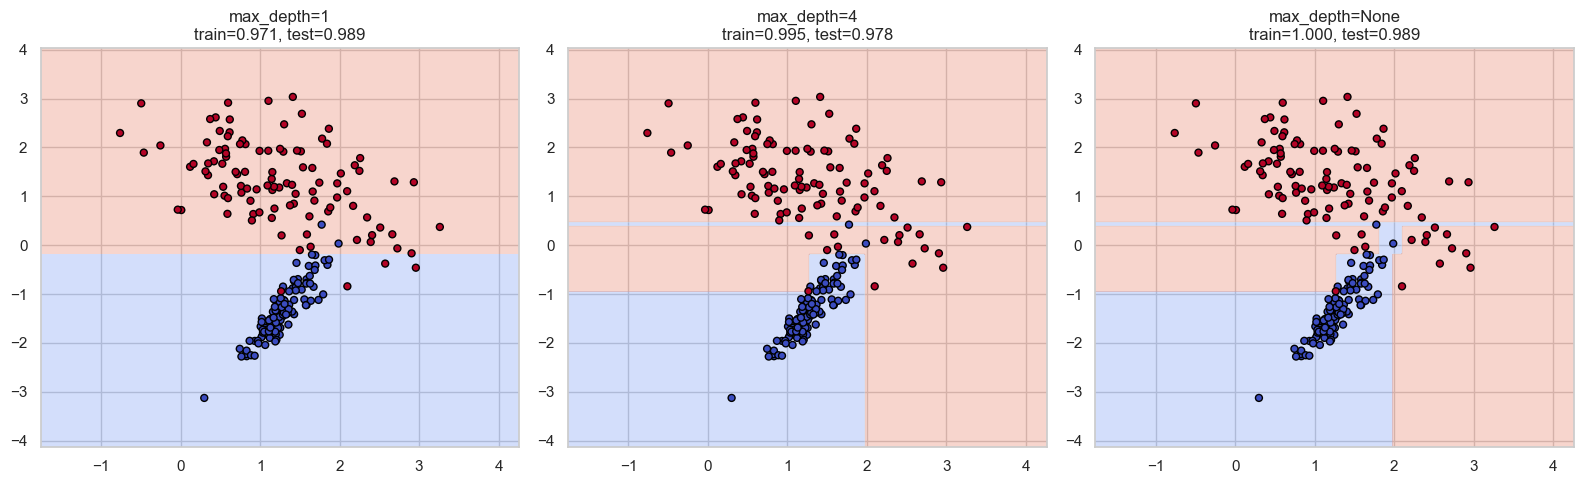

-> Unlimited depth (None) chases every training point perfectly (train accuracy near 1.0)
   but often generalizes worse than a shallower tree -- classic overfitting.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_2d, y_2d, test_size=0.3, stratify=y_2d, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, depth in zip(axes, [1, 4, None]):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    plot_tree_boundary(ax, model, X_train, y_train, f"max_depth={depth}\ntrain={train_acc:.3f}, test={test_acc:.3f}")
plt.tight_layout()
plt.show()

print("-> Unlimited depth (None) chases every training point perfectly (train accuracy near 1.0)")
print("   but often generalizes worse than a shallower tree -- classic overfitting.")


## 11. Pruning Parameters — `max_depth`, `min_samples_split`, `min_samples_leaf`

These three hyperparameters directly control tree complexity, trading training-data fit for generalization — the tree equivalent of Ridge/Lasso's regularization strength.


In [11]:
pruning_configs = [
    {"max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1},   # no pruning
    {"max_depth": 5, "min_samples_split": 2, "min_samples_leaf": 1},
    {"max_depth": None, "min_samples_split": 20, "min_samples_leaf": 10},  # pruned via leaf/split size instead of depth
]

for config in pruning_configs:
    model = DecisionTreeClassifier(random_state=42, **config)
    cv_score = cross_val_score(model, X_2d, y_2d, cv=5).mean()
    model.fit(X_2d, y_2d)
    print(f"{config} -> CV accuracy: {cv_score:.4f}, tree depth: {model.get_depth()}, leaves: {model.get_n_leaves()}")


{'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1} -> CV accuracy: 0.9700, tree depth: 4, leaves: 9
{'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1} -> CV accuracy: 0.9700, tree depth: 4, leaves: 9
{'max_depth': None, 'min_samples_split': 20, 'min_samples_leaf': 10} -> CV accuracy: 0.9700, tree depth: 4, leaves: 6


## 12. Feature Importance

A tree's feature importance is computed from how much each feature's splits reduce impurity, summed across every node it's used in, weighted by how many samples reach that node — the exact mechanism referenced (but not derived) back in the Foundation repo's Feature Engineering notebook.


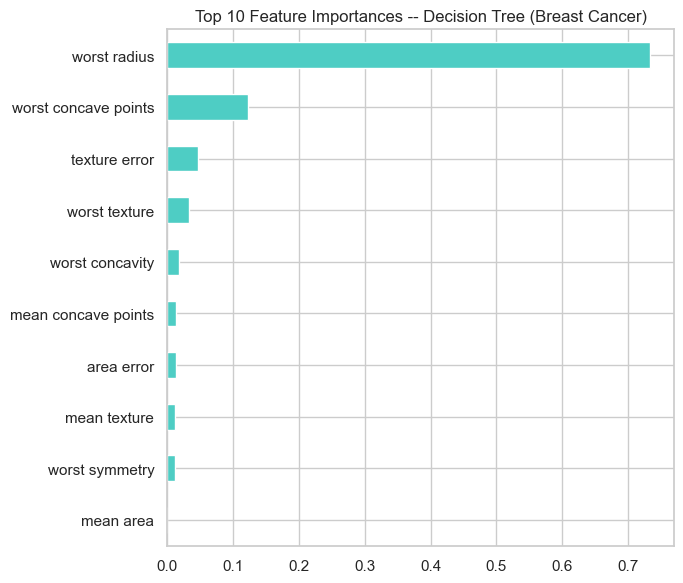

worst radius            0.733548
worst concave points    0.122028
texture error           0.045785
worst texture           0.032319
worst concavity         0.017161
mean concave points     0.013327
area error              0.012704
mean texture            0.011846
worst symmetry          0.011282
mean area               0.000000
dtype: float64


In [12]:
cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = cancer.data, cancer.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cancer, y_cancer, test_size=0.2, stratify=y_cancer, random_state=42)

cancer_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
cancer_tree.fit(X_train_c, y_train_c)

importance = pd.Series(cancer_tree.feature_importances_, index=cancer.feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
importance.head(10).plot(kind="barh", ax=ax, color="#4ecdc4")
ax.set_title("Top 10 Feature Importances -- Decision Tree (Breast Cancer)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.head(10))


## 13. Real Dataset — Breast Cancer, Full Evaluation


Test accuracy: 0.9386

               precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



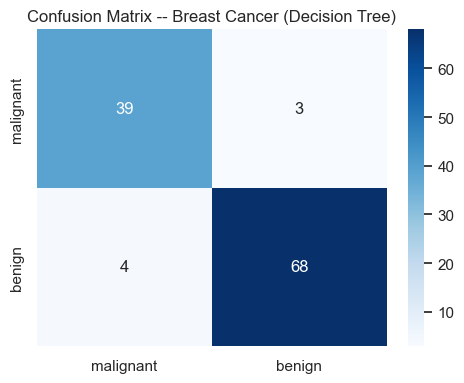

In [13]:
test_preds = cancer_tree.predict(X_test_c)
print(f"Test accuracy: {accuracy_score(y_test_c, test_preds):.4f}")
print("\n", classification_report(y_test_c, test_preds, target_names=cancer.target_names))

cm = confusion_matrix(y_test_c, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
ax.set_title("Confusion Matrix -- Breast Cancer (Decision Tree)")
plt.tight_layout()
plt.show()


## 14. Gini vs Entropy — Does the Criterion Choice Matter?

Both are valid impurity measures with similar behavior; the notebook checks whether switching between them changes real-world performance on this dataset.


In [14]:
for criterion in ["gini", "entropy", "log_loss"]:
    model = DecisionTreeClassifier(criterion=criterion, max_depth=4, random_state=42)
    score = cross_val_score(model, X_cancer, y_cancer, cv=5).mean()
    print(f"criterion={criterion:10s} -> CV accuracy: {score:.4f}")

print("\n-> Typically very close -- Gini and entropy usually agree on which splits are best,")
print("   differing mainly in computational cost (Gini avoids the log calculation, marginally faster).")


criterion=gini       -> CV accuracy: 0.9209
criterion=entropy    -> CV accuracy: 0.9420
criterion=log_loss   -> CV accuracy: 0.9420

-> Typically very close -- Gini and entropy usually agree on which splits are best,
   differing mainly in computational cost (Gini avoids the log calculation, marginally faster).


## 15. Instability — Small Data Changes, Different Trees

A known weakness: because splits are chosen greedily and exactly, a small change in the training data can cascade into a very different tree structure — the direct motivation for Random Forest (next notebook), which averages many trees to smooth this instability out.


In [15]:
np.random.seed(10)
root_features, root_thresholds, n_leaves = [], [], []

# Use the 30-feature Breast Cancer data -- more features means more close competition for "best split,"
# which makes resampling instability show up far more clearly than on the clean 2D toy data.
for trial in range(8):
    bootstrap_idx = np.random.choice(len(X_cancer), size=len(X_cancer), replace=True)   # resample with replacement
    X_boot, y_boot = X_cancer.values[bootstrap_idx], y_cancer.values[bootstrap_idx]
    model = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_boot, y_boot)
    root_features.append(cancer.feature_names[model.tree_.feature[0]])
    root_thresholds.append(round(model.tree_.threshold[0], 2))
    n_leaves.append(model.get_n_leaves())

instability_df = pd.DataFrame({
    "root_feature": root_features, "root_threshold": root_thresholds, "n_leaves": n_leaves,
})
print(instability_df)
print(f"\nUnique root features chosen across 8 resamples: {instability_df['root_feature'].nunique()}")
print("-> Different bootstrap resamples of the SAME dataset can pick different root features and thresholds --")
print("   this instability is exactly what Random Forest's bagging (many trees, averaged) smooths out.")


           root_feature  root_threshold  n_leaves
0       worst perimeter          114.40         9
1  worst concave points            0.14         8
2   mean concave points            0.05        12
3  worst concave points            0.15        11
4       worst perimeter          109.95        11
5  worst concave points            0.15        11
6   mean concave points            0.06        13
7       worst perimeter          113.15        11

Unique root features chosen across 8 resamples: 3
-> Different bootstrap resamples of the SAME dataset can pick different root features and thresholds --
   this instability is exactly what Random Forest's bagging (many trees, averaged) smooths out.


## ✅ Key Takeaways

- A decision tree learns a sequence of axis-aligned threshold rules — no probability model, no distance metric, no linear score. Its decision boundary is a distinctive rectangular "staircase."
- **Gini impurity** and **entropy/information gain** are the two standard criteria a tree greedily maximizes at every split — they usually agree closely in practice.
- Unconstrained trees **overfit dramatically** — near-perfect training accuracy with much worse test accuracy is the default behavior, not an edge case.
- `max_depth`, `min_samples_split`, and `min_samples_leaf` are the tree equivalent of Ridge/Lasso's regularization — always tune at least one of them via cross-validation.
- Feature importance falls out of the training process for free — no extra computation needed, unlike permutation importance (Foundation topic 04).
- Trees are **unstable**: small data changes can produce meaningfully different structures — this single weakness is the entire motivation for the next notebook, Random Forest.

**Next up:** [05_Random_Forest_Classifier](../05_Random_Forest_Classifier/) — an ensemble of many trees that directly fixes this instability.
